In [84]:
import pandas as pd
df = pd.read_csv('Fertilizer_recommendation.csv')
print(df.shape)
df.head()

(3100, 12)


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [85]:
df = df.drop('Remark',axis=1)
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer


In [86]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
dtypes: float64(8), object(3)
memory usage: 266.5+ KB
None
       Temperature     Moisture     Rainfall           PH     Nitrogen  \
count  3100.000000  3100.000000  3100.000000  3100.000000  3100.000000   
mean     27.271096     0.600763   111.024949     6.379775    61.278480   
std       9.114450     0.144947    77.151880     0.957103    10.18

In [87]:
print(df['Crop'].unique())
print(df['Soil'].unique())
print(df['Fertilizer'].unique())

['rice' 'wheat' 'Mung Bean' 'Tea' 'millet' 'maize' 'Lentil' 'Jute'
 'Coffee' 'Cotton' 'Ground Nut' 'Peas' 'Rubber' 'Sugarcane' 'Tobacco'
 'Kidney Beans' 'Moth Beans' 'Coconut' 'Black gram' 'Adzuki Beans'
 'Pigeon Peas' 'Chickpea' 'banana' 'grapes' 'apple' 'mango' 'muskmelon'
 'orange' 'papaya' 'pomegranate' 'watermelon']
['Loamy Soil' 'Peaty Soil' 'Acidic Soil' 'Neutral Soil' 'Alkaline Soil']
['Compost' 'Balanced NPK Fertilizer' 'Water Retaining Fertilizer'
 'Organic Fertilizer' 'Gypsum' 'Lime' 'DAP' 'Urea' 'Muriate of Potash'
 'General Purpose Fertilizer']


In [88]:
fert_to_crop = {
    'Adzuki Beans': 'mothbeans',   
    'Black gram': 'blackgram',
    'Chickpea': 'chickpea',
    'Coconut': 'coconut',
    'Coffee': 'coffee',
    'Cotton': 'cotton',
    'Ground Nut': 'mothbeans',       
    'Jute': 'jute',
    'Kidney Beans': 'kidneybeans',
    'Lentil': 'lentil',
    'Moth Beans': 'mothbeans',
    'Mung Bean': 'mungbean',
    'Peas': 'chickpea',              
    'Pigeon Peas': 'pigeonpeas',
    'Rubber': 'coconut',            
    'Tobacco': 'cotton',             
    'apple': 'apple',
    'banana': 'banana',
    'grapes': 'grapes',
    'maize': 'maize',
    'mango': 'mango',
    'millet': 'maize',              
    'muskmelon': 'muskmelon',
    'orange': 'orange',
    'papaya': 'papaya',
    'pomegranate': 'pomegranate',
    'rice': 'rice',
    'watermelon': 'watermelon',
    'wheat': 'rice'                  
}


In [89]:
df['Crop'] = df['Crop'].map(fert_to_crop)
df = df.dropna(subset=['Crop']) 
df['Crop'].unique()

array(['rice', 'mungbean', 'maize', 'lentil', 'jute', 'coffee', 'cotton',
       'mothbeans', 'chickpea', 'coconut', 'kidneybeans', 'blackgram',
       'pigeonpeas', 'banana', 'grapes', 'apple', 'mango', 'muskmelon',
       'orange', 'papaya', 'pomegranate', 'watermelon'], dtype=object)

In [90]:
from sklearn.preprocessing import LabelEncoder
col_to_encode = ['Soil','Crop','Fertilizer']
encoder = {}
for col in col_to_encode:
    le = LabelEncoder()
    df[col+'_en'] = le.fit_transform(df[col])
    encoder[col] = le

In [91]:
soiltype_maping = list(zip(encoder['Soil'].classes_,encoder['Soil'].transform(encoder['Soil'].classes_)))
print(soiltype_maping)

[('Acidic Soil', np.int64(0)), ('Alkaline Soil', np.int64(1)), ('Loamy Soil', np.int64(2)), ('Neutral Soil', np.int64(3)), ('Peaty Soil', np.int64(4))]


In [92]:
croptype_maping = list(zip(encoder['Crop'].classes_,encoder['Crop'].transform(encoder['Crop'].classes_)))
print(croptype_maping)

[('apple', np.int64(0)), ('banana', np.int64(1)), ('blackgram', np.int64(2)), ('chickpea', np.int64(3)), ('coconut', np.int64(4)), ('coffee', np.int64(5)), ('cotton', np.int64(6)), ('grapes', np.int64(7)), ('jute', np.int64(8)), ('kidneybeans', np.int64(9)), ('lentil', np.int64(10)), ('maize', np.int64(11)), ('mango', np.int64(12)), ('mothbeans', np.int64(13)), ('mungbean', np.int64(14)), ('muskmelon', np.int64(15)), ('orange', np.int64(16)), ('papaya', np.int64(17)), ('pigeonpeas', np.int64(18)), ('pomegranate', np.int64(19)), ('rice', np.int64(20)), ('watermelon', np.int64(21))]


In [93]:
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Soil_en,Crop_en,Fertilizer_en
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,2,20,1
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,2,20,0
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,4,20,9
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,2,20,0
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,4,20,7


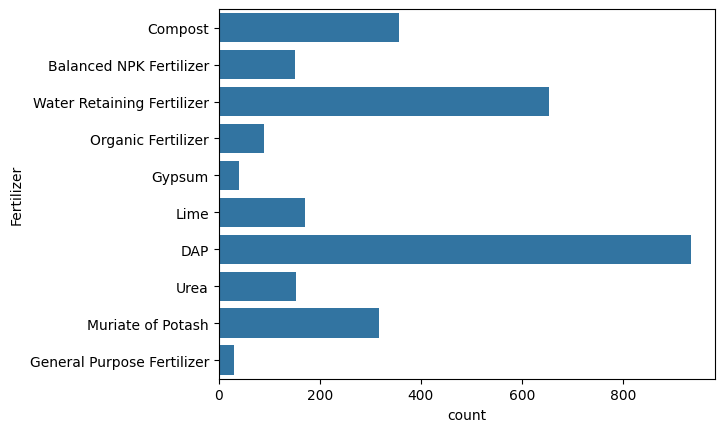

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(df['Fertilizer'])
plt.show()

In [95]:
df = df.drop(['Fertilizer','Soil','Crop'],axis=1)
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil_en,Crop_en,Fertilizer_en
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,20,1
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,20,0
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,20,9
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,20,0
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,20,7


In [96]:
x = df.drop('Fertilizer_en',axis=1)
y = df['Fertilizer_en']
print(x.shape)
print(y.shape)

(2900, 10)
(2900,)


In [97]:
x.columns

Index(['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous',
       'Potassium', 'Carbon', 'Soil_en', 'Crop_en'],
      dtype='object')

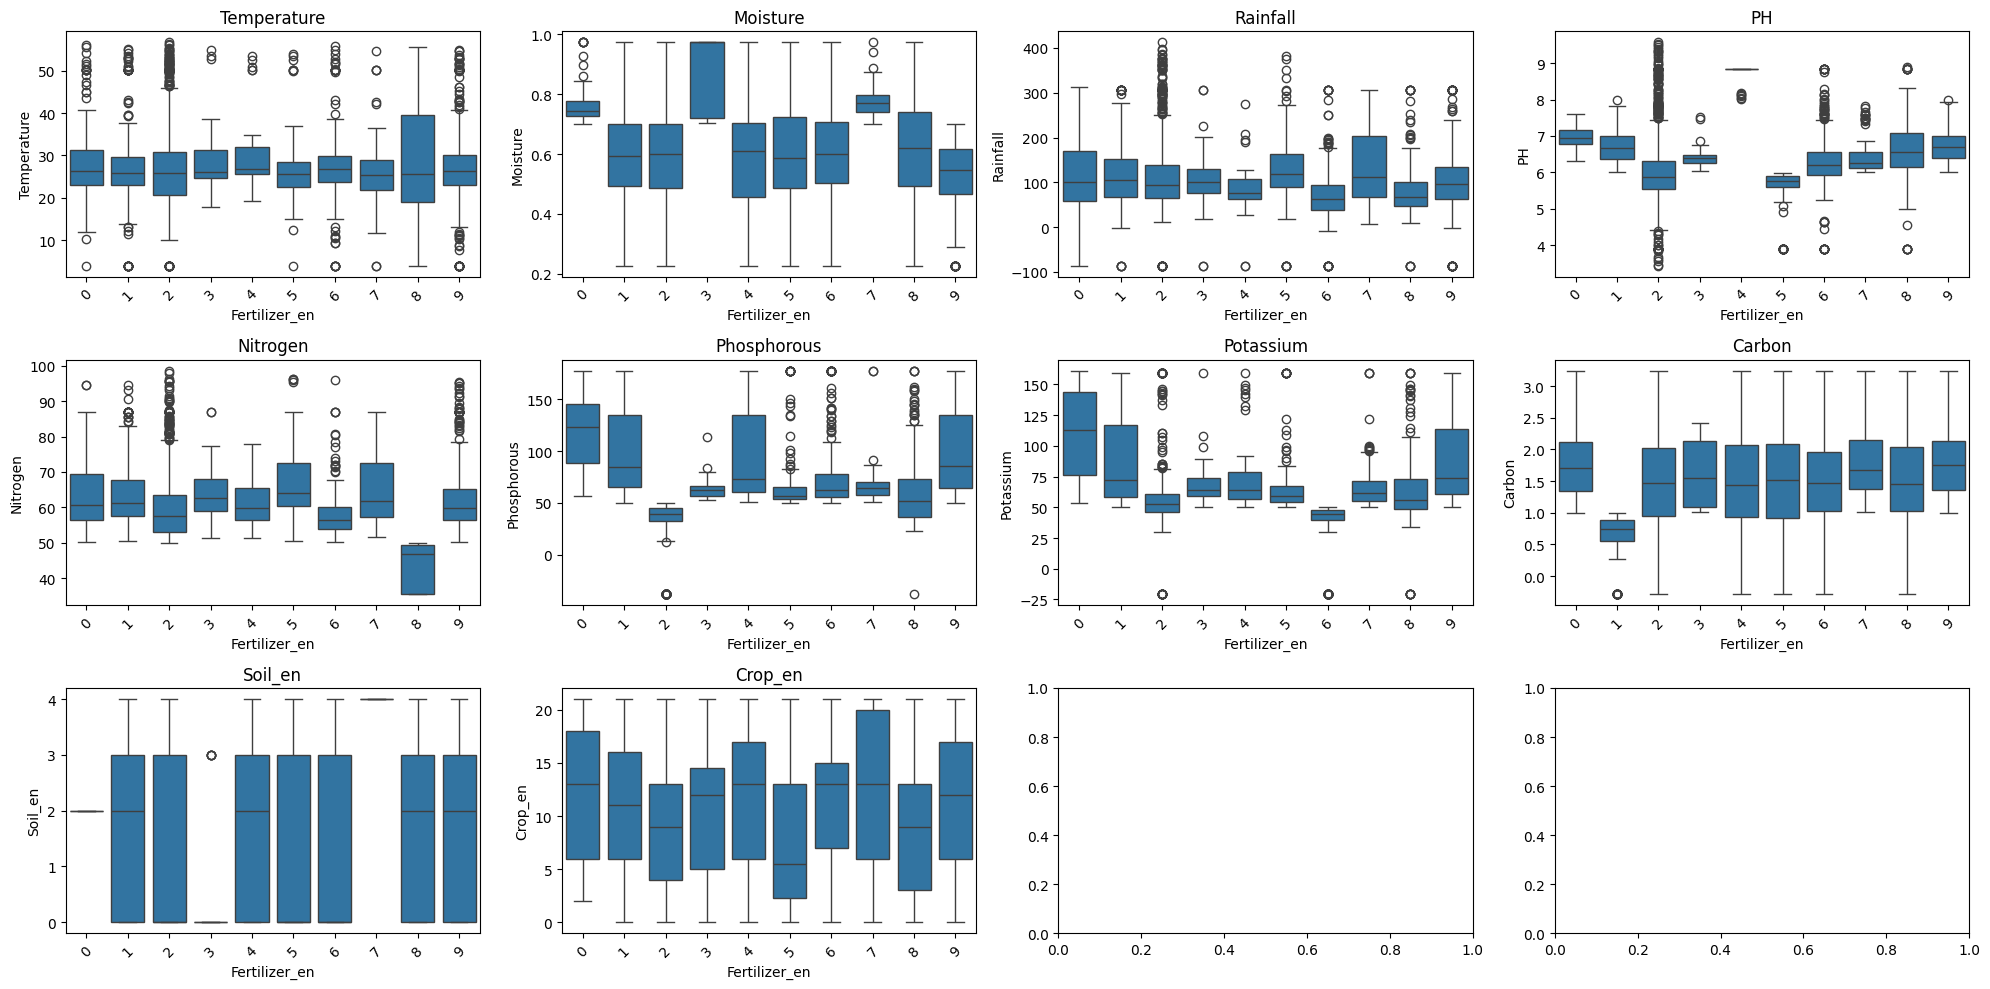

In [98]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(x.columns):  # x = df.drop('label', axis=1)
    sns.boxplot(data=df, x='Fertilizer_en', y=feature, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [99]:
def remove_outlier(df,col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1

    lower = q1-1.5*IQR
    upper = q3+1.5*IQR

    df = df[(df[col]>lower)&(df[col]<upper)]
    return df
for i in x.columns:
    df = remove_outlier(df,i)
df.shape

(1559, 11)

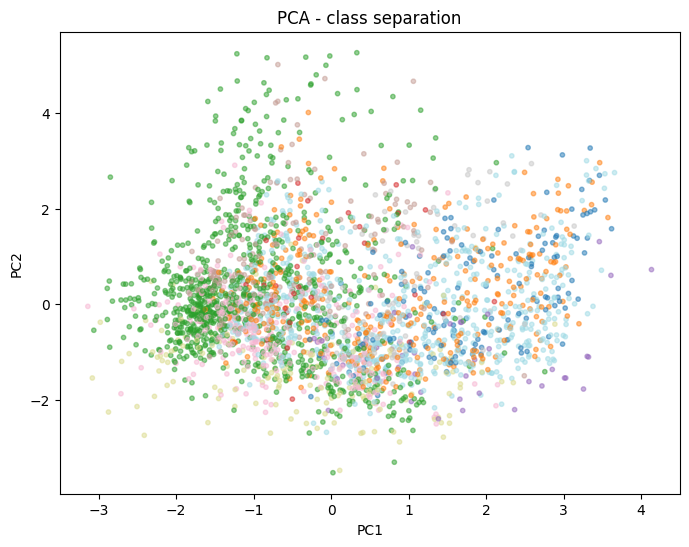

In [100]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab20', s=10, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - class separation')
plt.show()


In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [102]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ('scaler', StandardScaler()),
    ('kbest', SelectKBest(score_func=f_classif, k=15)),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=1,          
    ))
])

param_grid = {
    'kbest__k': [3,5,7],           
    'model__n_estimators': [50,100], 
    'model__max_depth': [10,30],  
}


grid_rf = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,              
    scoring='accuracy',
    n_jobs=1, 
)

grid_rf.fit(x_train, y_train)
y_predict = grid_rf.predict(x_test)
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       0.99      1.00      0.99        71
           2       0.99      1.00      0.99       187
           3       1.00      1.00      1.00         6
           4       1.00      0.88      0.93         8
           5       1.00      0.97      0.99        34
           6       1.00      0.98      0.99        63
           7       1.00      1.00      1.00        18
           8       1.00      1.00      1.00        31
           9       0.99      0.99      0.99       131

    accuracy                           0.99       580
   macro avg       1.00      0.98      0.99       580
weighted avg       0.99      0.99      0.99       580



In [106]:
import joblib 
joblib.dump(encoder['Soil'],'soil_encode.plk')
joblib.dump(encoder['Crop'],'ferti_crop_encode.plk')
joblib.dump(grid_rf,'fertilizer.plk')
joblib.dump(encoder['Fertilizer'],'fertilizer_encode.plk')

['fertilizer_encode.plk']